<a href="https://colab.research.google.com/github/GEE2007/spotify-genre-classification/blob/main/spotify_genre_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name**    -



##### **Project Type**    - Classification
##### **Contribution**    - Individual
##### **Team Member 1 -** - Geetika

# **Project Summary -**

*Music streaming platforms contain millions of songs belonging to different genres, making automatic genre classification an important task for improving recommendation systems, playlist generation, and music discovery. The objective of this project was to build a machine learning model capable of classifying songs into their respective genres using Spotify audio features.*

*The Spotify Tracks dataset was used for this project. Since the original dataset was large, a random sample of approximately 20,000 records was selected to reduce computational time while maintaining sufficient data for analysis and model building. The dataset contained various numerical audio features such as popularity, danceability, energy, loudness, speechiness, acousticness, instrumentalness, liveness, valence, tempo, and time signature, along with information about artists, albums, and track genres.*

*The project began with data preprocessing and exploratory data analysis (EDA). Missing values and duplicate records were checked, and appropriate preprocessing steps were performed. Categorical variables were encoded into numerical values to make them suitable for machine learning algorithms. New features such as artist_count, album_song_count, and album_avg_popularity were created to provide additional information about collaboration patterns and album characteristics. Text-based columns such as track ID, track name, artists, and album name were removed after feature engineering because they could not be directly used by traditional machine learning models.*

*Several visualizations were created to better understand the dataset. Charts showing average popularity, danceability, song duration, explicit content distribution, popularity distribution, collaboration trends, genre frequency, and album popularity helped identify meaningful patterns in the data. Correlation heatmaps and pair plots were also generated to examine relationships among numerical features.*

*The dataset was divided into training and testing sets using an 80:20 ratio. Feature scaling was applied where required before training the models. Three classification algorithms were selected for comparison: Logistic Regression, Gradient Boosting, and Random Forest. Logistic Regression served as the baseline model, while Gradient Boosting and Random Forest represented ensemble learning techniques capable of capturing more complex relationships in the data.*

*Model performance was evaluated using Accuracy, Precision, Recall, and F1-score. Hyperparameter tuning was performed using GridSearchCV with cross-validation to identify better-performing parameter combinations. The tuned models were compared with their default versions to analyze whether any significant improvements were achieved.*

*Among all the models, Random Forest achieved the highest predictive performance, followed by Gradient Boosting and Logistic Regression. Feature importance analysis showed that audio characteristics such as energy, danceability, loudness, acousticness, tempo, and popularity played a major role in predicting song genres. These findings demonstrate that audio-based features provide meaningful information for genre classification and recommendation systems.*

*Overall, the project successfully implemented a complete machine learning workflow including data preprocessing, exploratory analysis, feature engineering, model building, hyperparameter tuning, and performance evaluation. The developed model can assist music streaming platforms in automatically classifying songs, improving recommendation quality, and enhancing the overall user listening experience.*

# **GitHub Link -**

https://github.com/GEE2007/spotify-genre-classification

# **Problem Statement**


**Music streaming platforms contain millions of songs from diverse genres, making manual genre classification difficult and time-consuming. Accurate genre classification is essential for improving music recommendations, playlist generation, and content organization. The objective of this project is to build a machine learning classification model that predicts the genre of a Spotify track using its audio features such as danceability, energy, loudness, acousticness, tempo, and other musical characteristics. The project also aims to compare different classification algorithms to identify the model that provides the best performance for genre prediction.**

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [73]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Dataset Loading

In [ ]:
# Load Dataset
import os
import kagglehub

# Download latest version
path = kagglehub.dataset_download("saichaitanyareddyai/spotify-tracks-dataset-audio-features")

print("Path to dataset files:", path)
print(os.listdir(path))
df = pd.read_csv(os.path.join(path, "spotify-tracks-dataset-detailed.csv"))

100%|██████████| 7.90M/7.90M [00:00<00:00, 123MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/saichaitanyareddyai/spotify-tracks-dataset-audio-features/versions/1
['spotify-tracks-dataset-detailed.csv']


### Dataset First View

In [ ]:
# Dataset First Look
df.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


### Dataset Rows & Columns count

In [ ]:
# Dataset Rows & Columns count
df.shape

(114000, 20)

In [ ]:
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

In [ ]:
df = df.sample(n=20000, random_state=42)

### Dataset Information

In [ ]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20000 entries, 113186 to 17149
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   track_id          20000 non-null  object 
 1   artists           20000 non-null  object 
 2   album_name        20000 non-null  object 
 3   track_name        20000 non-null  object 
 4   popularity        20000 non-null  int64  
 5   duration_ms       20000 non-null  int64  
 6   explicit          20000 non-null  bool   
 7   danceability      20000 non-null  float64
 8   energy            20000 non-null  float64
 9   key               20000 non-null  int64  
 10  loudness          20000 non-null  float64
 11  mode              20000 non-null  int64  
 12  speechiness       20000 non-null  float64
 13  acousticness      20000 non-null  float64
 14  instrumentalness  20000 non-null  float64
 15  liveness          20000 non-null  float64
 16  valence           20000 non-null  float6

#### Duplicate Values

In [ ]:
# Dataset Duplicate Value Count
df.duplicated().sum()

np.int64(17)

#### Missing Values/Null Values

In [ ]:
# Missing Values/Null Values Count
df.isnull().sum()

,0
track_id,0
artists,0
album_name,0
track_name,0
popularity,0
duration_ms,0
explicit,0
danceability,0
energy,0
key,0


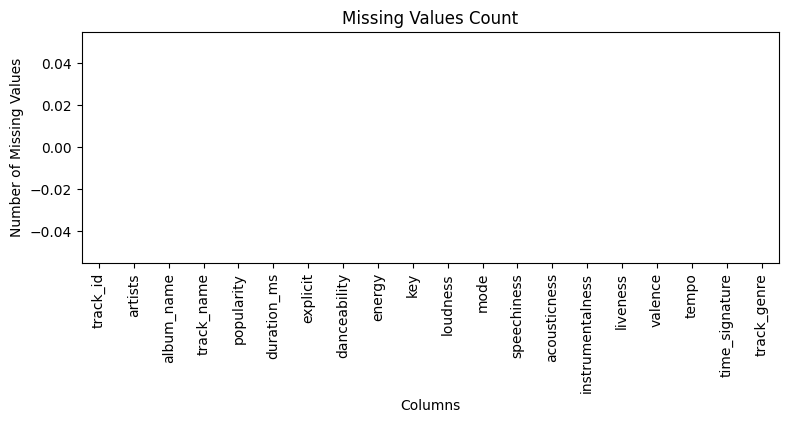

In [ ]:
# Visualizing the missing values
df.isnull().sum().plot(kind='bar', figsize=(9,3))
plt.title("Missing Values Count")
plt.xlabel("Columns")
plt.ylabel("Number of Missing Values")
plt.show()

### What did you know about your dataset?

* *The dataset contains 20,000 songs and 20 columns after random sampling from the original dataset.*
* *It includes information such as artist name, album name, track name, popularity, duration, danceability, energy, loudness, tempo, and other audio features.*
* *The target variable is track_genre, which represents the genre of each song.*
* *The dataset contains different data types including numerical, categorical, and boolean features.*
* *It is a multiclass classification dataset because it contains multiple music genres.*

## ***2. Understanding Your Variables***

In [ ]:
# Dataset Columns
df.columns

Index(['track_id', 'artists', 'album_name', 'track_name', 'popularity',
       'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness',
       'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'time_signature', 'track_genre'],
      dtype='object')

In [ ]:
# Dataset Describe
df.describe()

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,20000.000000,2.000000e+04,20000.000000,20000.000000,20000.00000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000
mean,33.199700,2.269323e+05,0.567058,0.642218,5.28175,-8.246955,0.642000,0.084663,0.314074,0.158173,0.213357,0.475482,122.163859,3.89975
std,22.241833,9.738991e+04,0.174293,0.252224,3.54790,5.031660,0.479424,0.105436,0.331604,0.311655,0.189525,0.259418,30.058054,0.44532
min,0.000000,2.124000e+04,0.000000,0.000020,0.00000,-43.943000,0.000000,0.000000,0.000000,0.000000,0.011200,0.000000,0.000000,0.00000
25%,17.000000,1.730588e+05,0.454000,0.472000,2.00000,-10.012500,0.000000,0.035800,0.016500,0.000000,0.098300,0.262000,99.777500,4.00000
50%,35.000000,2.125130e+05,0.581000,0.687000,5.00000,-6.983000,1.000000,0.048800,0.168000,0.000045,0.132000,0.465000,122.001500,4.00000
75%,50.000000,2.609340e+05,0.698000,0.855000,8.00000,-4.999000,1.000000,0.084125,0.595000,0.052225,0.275000,0.685000,140.028250,4.00000
max,100.000000,3.600120e+06,0.984000,1.000000,11.00000,4.532000,1.000000,0.965000,0.996000,0.999000,0.995000,0.993000,220.084000,5.00000


### Variables Description

* *track_id: Unique ID assigned to each Spotify track.*
* *artists: Name of the artist or artists who performed the song.*
* *album_name: Name of the album in which the song appears.*
* *track_name: Name of the song.*
* *popularity: Popularity score of the song ranging from 0 to 100.*
* *duration_ms: Duration of the song in milliseconds.*
* *explicit: Indicates whether the song contains explicit lyrics (True/False).*
* *danceability: Measures how suitable the song is for dancing. Values range from 0 to 1.*
* *energy: Represents the intensity and activity level of the song. Values range from 0 to 1.*
* *key: Musical key in which the song is composed (values from 0 to 11).*
* *loudness: Overall loudness of the song measured in decibels (dB).*
* *mode: Indicates whether the song is in Major (1) or Minor (0) mode.*
* *speechiness: Measures the presence of spoken words in the song. Values range from 0 to 1.*
* *acousticness: Measures how acoustic the song is. Values range from 0 to 1.*
* *instrumentalness: Predicts whether the song contains no vocals. Values range from 0 to 1.*
* *liveness: Measures the likelihood that the song was performed live. Values range from 0 to 1.*
* *valence: Describes the musical positivity or happiness of the song. Values range from 0 to 1.*
* *tempo: Estimated speed of the song measured in beats per minute (BPM).*
* *time_signature: Indicates the number of beats in each musical measure.*
* *track_genre: Represents the genre of the song. This is the target variable used for multiclass classification.*

### Check Unique Values for each variable.

In [ ]:
# Check Unique Values for each variable.
for column in df.columns:
    print(f"{column}: {df[column].nunique()}")

track_id: 19016
artists: 10709
album_name: 13644
track_name: 17190
popularity: 98
duration_ms: 15077
explicit: 2
danceability: 939
energy: 1370
key: 12
loudness: 10110
mode: 2
speechiness: 1271
acousticness: 3732
instrumentalness: 4074
liveness: 1564
valence: 1517
tempo: 14304
time_signature: 5
track_genre: 114


## 3. ***Data Wrangling***

### Data Wrangling Code

In [ ]:
# Write your code to make your dataset analysis ready.
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

### What all manipulations have you done and insights you found?

* *Shuffled the dataset randomly to remove the original genre-wise ordering.*
* *Selected a random sample of 20,000 records from the original dataset to reduce computation time while maintaining data diversity.*
* *Reset the index after sampling to keep the dataset organized.
Checked for missing values and found no missing values, so no treatment was required.*
* *Checked for duplicate records and found 17 duplicate rows. Since they were a very small portion of the dataset (17 out of 20,000), they were removed to improve data quality.*
* *Checked the unique values of each feature to better understand the dataset.*

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

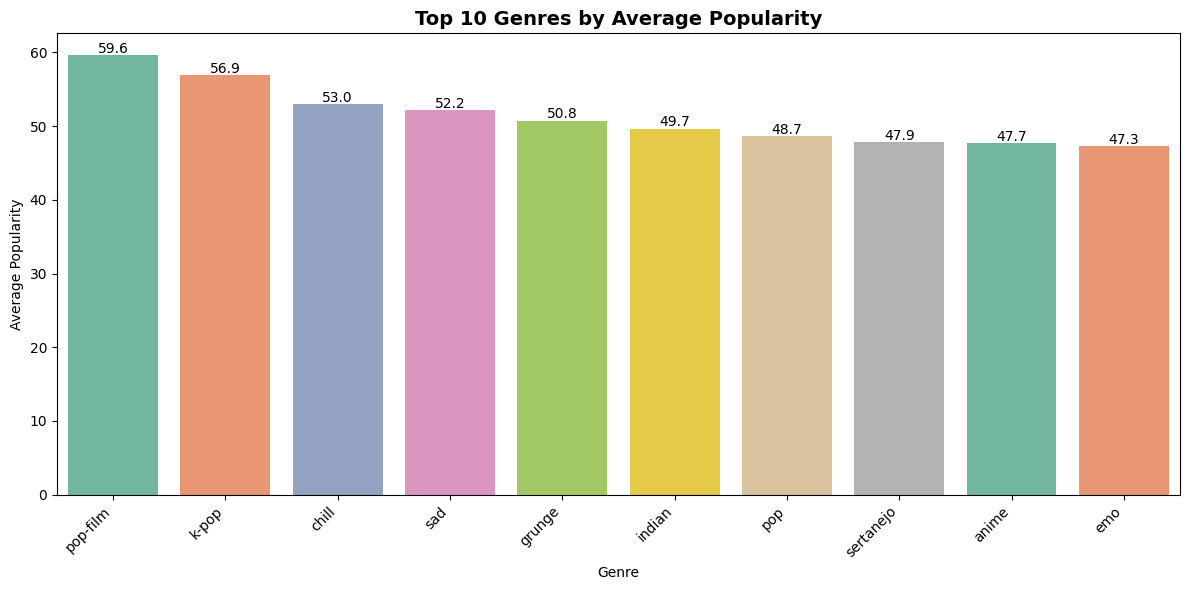

In [ ]:
# Chart - 1 visualization code
top_popularity = (
    df.groupby("track_genre")["popularity"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

ax = sns.barplot(
    x=top_popularity.index,
    y=top_popularity.values,
    hue=top_popularity.index,
    palette="Set2",
    legend=False
)

plt.title("Top 10 Genres by Average Popularity", fontsize=14, fontweight="bold")
plt.xlabel("Genre")
plt.ylabel("Average Popularity")

plt.xticks(rotation=45, ha="right")

for i, v in enumerate(top_popularity.values):
    ax.text(i, v+0.3, f"{v:.1f}", ha="center")

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?



* *A bar chart is used to compare the average popularity of different music genres.*
* *It helps identify which genres receive higher listener engagement on Spotify.*


##### 2. What is/are the insight(s) found from the chart?

* *Pop-film has the highest average popularity (59.6), followed by K-pop (56.9) and Chill (53.0).*
* *Genres like Sad, Grunge, Indian, Pop, Sertanejo, Anime, and Emo also appear among the top 10 popular genres.*
* *This shows that listeners enjoy a mix of mainstream, regional, and niche music genres.*

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.


**Business Impact:**

* *Spotify can recommend these popular genres to increase user engagement.*
* *Music producers can understand which genres are currently attracting more listeners.*

**Negative Growth:**

* *No such negative growth.*

#### Chart - 2

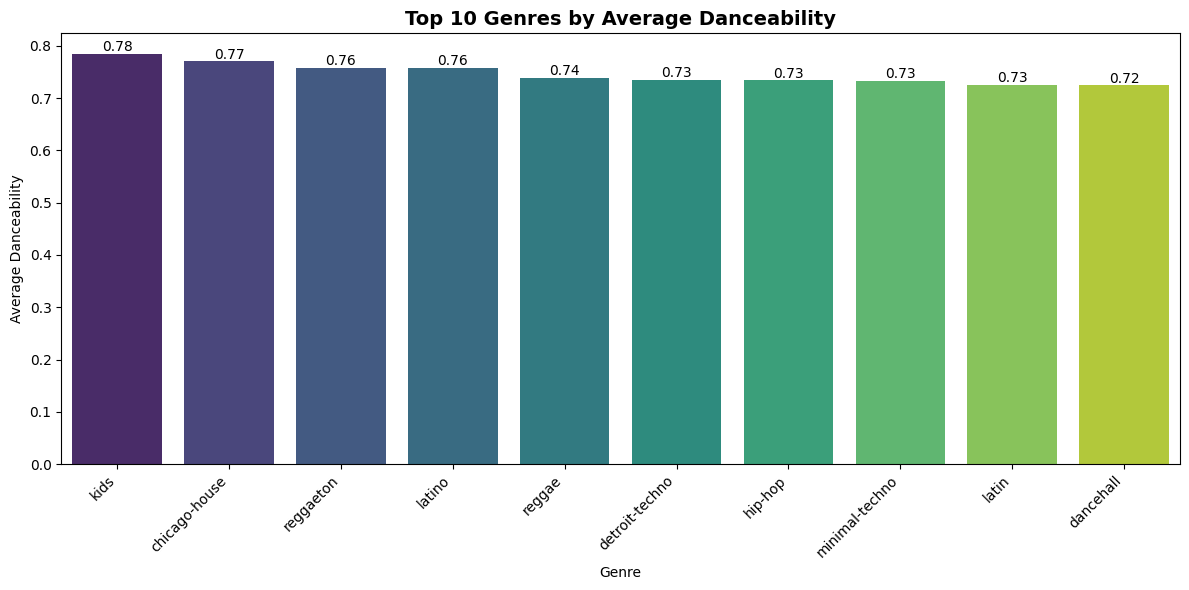

In [ ]:
# Chart - 2 visualization code
top_dance = (
    df.groupby("track_genre")["danceability"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

ax = sns.barplot(
    x=top_dance.index,
    y=top_dance.values,
    hue=top_dance.index,
    palette="viridis",
    legend=False
)

plt.title("Top 10 Genres by Average Danceability", fontsize=14, fontweight="bold")
plt.xlabel("Genre")
plt.ylabel("Average Danceability")

plt.xticks(rotation=45, ha="right")

for i, v in enumerate(top_dance.values):
    ax.text(i, v+0.005, f"{v:.2f}", ha="center")

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

* *Here a bar chart is used to compare the danceability of different music genres.*
* *It helps identify genres suitable for dance and party playlists.*

##### 2. What is/are the insight(s) found from the chart?

* *Kids music has the highest average danceability (0.78).*
* *Most highly danceable genres belong to electronic, Latin, and dance music categories.*

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Business Impact:**

* *Spotify can recommend these genres for party, workout, and dance playlists.*
* *Playlist creators can use these insights to improve user experience.*
**Negative Growth:**
* *No such negative growth*

#### Chart - 3

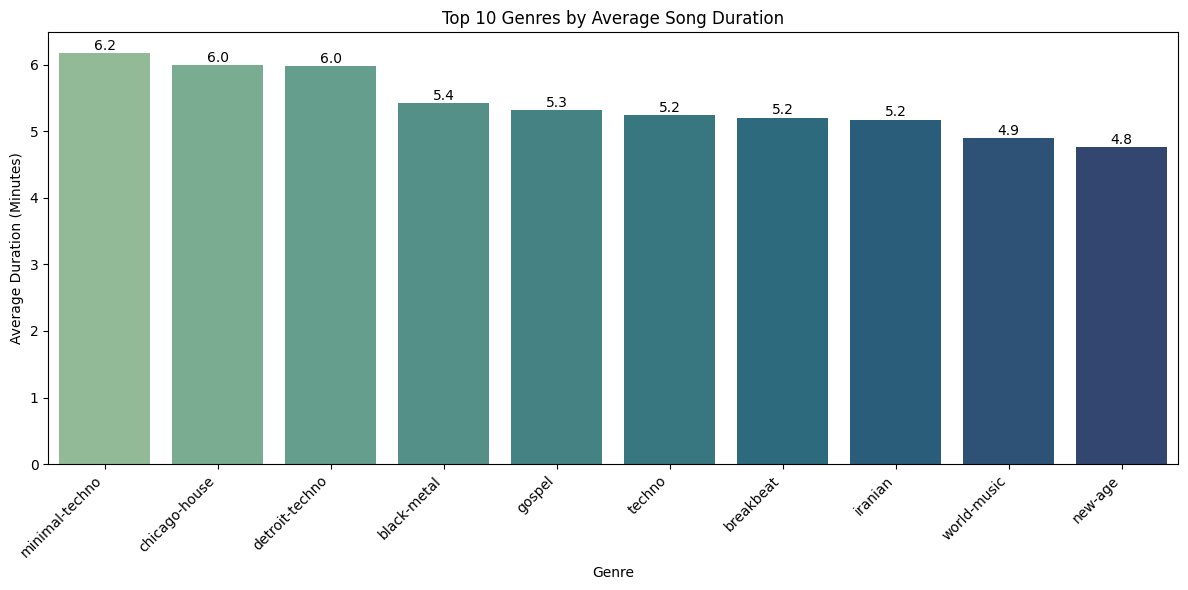

In [ ]:
# Chart - 3 visualization code
top_duration = (
    df.groupby("track_genre")["duration_ms"]
    .mean()
    .sort_values(ascending=False)
    .head(10) / 60000
)

plt.figure(figsize=(12,6))

ax = sns.barplot(
    x=top_duration.index,
    y=top_duration.values,
    hue=top_duration.index,
    palette="crest",
    legend=False
)

plt.title("Top 10 Genres by Average Song Duration")
plt.xlabel("Genre")
plt.ylabel("Average Duration (Minutes)")
plt.xticks(rotation=45, ha="right")

for i,v in enumerate(top_duration.values):
    ax.text(i,v+0.05,f"{v:.1f}",ha="center")

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

* *A bar chart is suitable for comparing the average song duration across different genres.*
* *It makes it easy to identify genres with longer songs.*

##### 2. What is/are the insight(s) found from the chart?


* *Minimal-Techno has the highest average song duration (6.2 minutes).*
* *Genres such as Chicago-House, Detroit-Techno, Black-Metal, Gospel, Techno, Breakbeat, Iranian, World-Music, and New Age also have longer average song durations.*
* *This shows that electronic, instrumental, and traditional music genres generally have longer songs than many mainstream genres.*


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Business Impact:**

* *Music streaming platforms can recommend longer songs for users who enjoy extended listening sessions.*
* *Playlist creators can design playlists based on preferred song duration.*

**Negative Growth:**

* *No significant negative business impact was observed from this analysis.*

#### Chart - 4

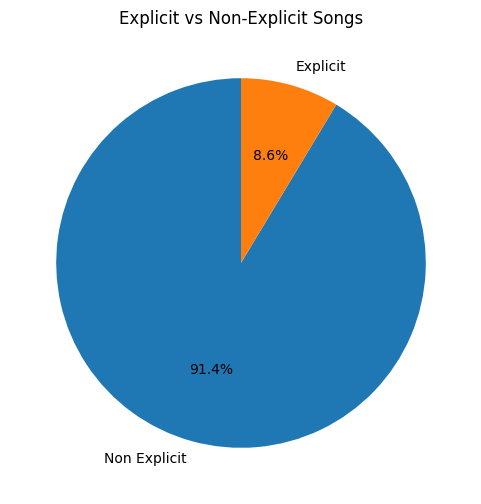

In [ ]:
# Chart - 4 visualization code
explicit = df["explicit"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    explicit,
    labels=["Non Explicit","Explicit"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Explicit vs Non-Explicit Songs")

plt.show()

##### 1. Why did you pick the specific chart?

* *A pie chart is suitable for showing the proportion of different categories.*
* *It clearly compares the percentage of explicit and non-explicit songs.*

##### 2. What is/are the insight(s) found from the chart?

* *Around 91.4% of the songs are non-explicit.*
* *Only 8.6% of the songs are explicit.*
* *This indicates that most songs in the dataset are suitable for a general audience.*

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Business Impact**

* *Spotify can recommend more family-friendly playlists.*
* *Advertisers and playlist creators can better target different listener groups.*

**Negative Growth**

* *Since explicit songs form a smaller portion of the dataset, user preferences for explicit content may not be fully represented.*

#### Chart - 5

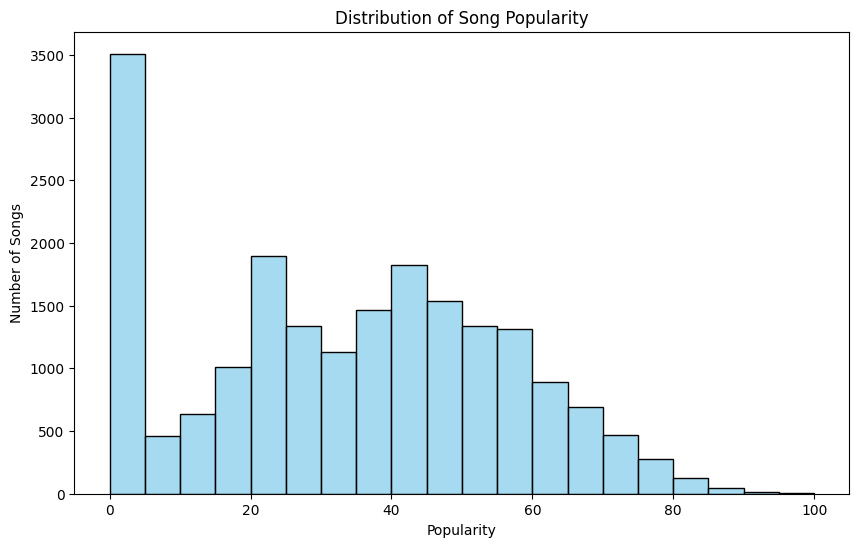

In [ ]:
# Chart - 5 visualization code
plt.figure(figsize=(10,6))

sns.histplot(
    df["popularity"],
    bins=20,
    color="skyblue"
)

plt.title("Distribution of Song Popularity")
plt.xlabel("Popularity")
plt.ylabel("Number of Songs")

plt.show()

##### 1. Why did you pick the specific chart?

* *A histogram is useful for showing how numerical data is distributed.*
* *It helps understand how song popularity is spread across the dataset.*

##### 2. What is/are the insight(s) found from the chart?

* *A large number of songs have very low popularity.*
* *Most songs have popularity values between 20 and 60.*
* *Very few songs achieve extremely high popularity scores.*

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Business Impact:**

* *Spotify can identify highly popular songs for recommendations while also promoting less popular songs to increase their visibility.*
* *Music companies can analyze why only a small number of songs become highly popular.*

**Negative Growth**

* *Since only a few songs have very high popularity, focusing only on those songs may reduce the exposure of other quality tracks.*

#### Chart - 6

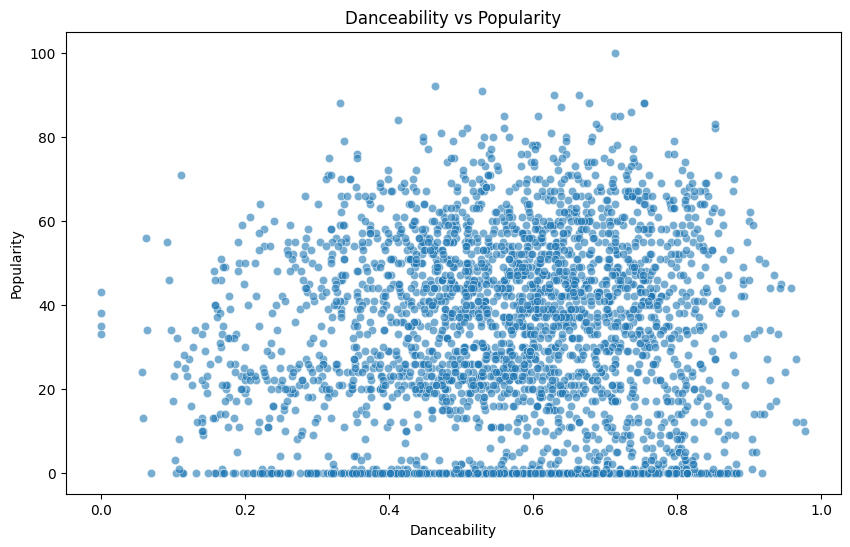

In [ ]:
# Chart - 6 visualization code
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df.sample(3000, random_state=42),
    x="danceability",
    y="popularity",
    alpha=0.6
)

plt.title("Danceability vs Popularity")
plt.xlabel("Danceability")
plt.ylabel("Popularity")

plt.show()

##### 1. Why did you pick the specific chart?

* *A scatter plot is useful for showing the relationship between two numerical variables.*
* *It helps identify whether danceability affects song popularity.*

##### 2. What is/are the insight(s) found from the chart?

* *There is a weak positive relationship between danceability and popularity.*
* *Songs with medium to high danceability generally have higher popularity.*
* *However, danceability alone does not determine a song's popularity.*

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Business Impact:**

* *Spotify can consider danceability as one of the factors while recommending songs.*
* *Music producers can understand that danceability may improve listener engagement but should not be the only focus.*

**Negative Growth / Limitation:**

* *Since the relationship is weak, relying only on danceability may lead to inaccurate recommendations.*

#### Chart - 7

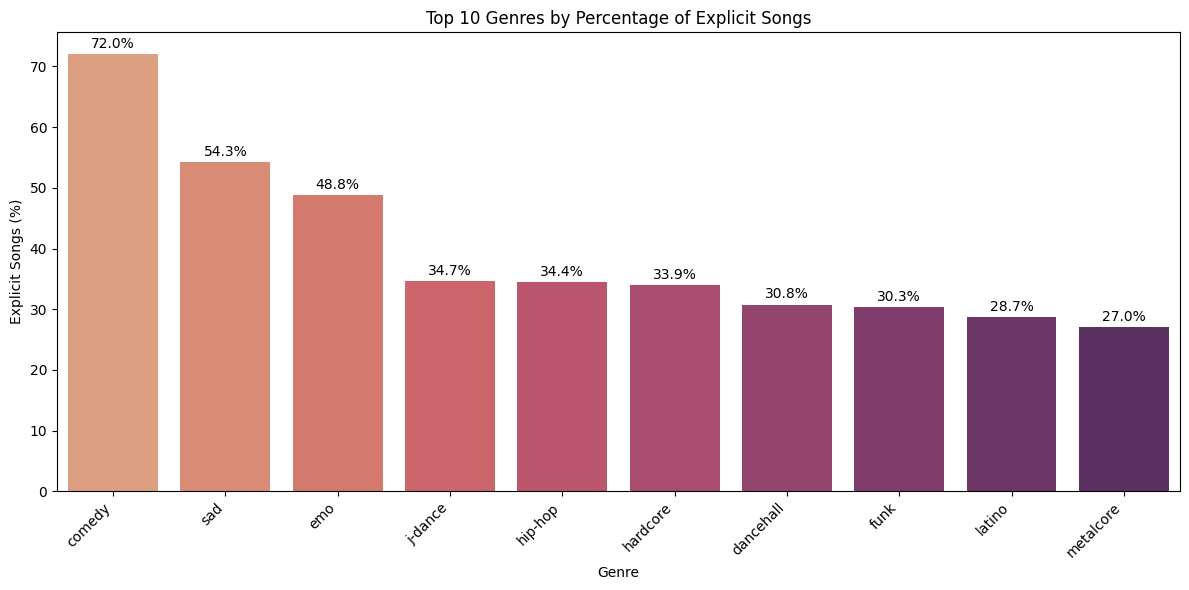

In [ ]:
# Chart - 7 visualization code
genre_explicit = (
    df.groupby("track_genre")["explicit"]
    .mean()
    .sort_values(ascending=False)
    .head(10) * 100
)

plt.figure(figsize=(12,6))

ax = sns.barplot(
    x=genre_explicit.index,
    y=genre_explicit.values,
    hue=genre_explicit.index,
    palette="flare",
    legend=False
)

plt.title("Top 10 Genres by Percentage of Explicit Songs")
plt.xlabel("Genre")
plt.ylabel("Explicit Songs (%)")
plt.xticks(rotation=45, ha="right")

for i,v in enumerate(genre_explicit.values):
    ax.text(i,v+1,f"{v:.1f}%",ha="center")

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

* *A bar chart is useful for comparing the percentage of explicit songs across different genres.*
* *It clearly highlights genres with a higher proportion of explicit content.*


##### 2. What is/are the insight(s) found from the chart?

* *Comedy has the highest percentage of explicit songs (72%).*
* *Sad (54.3%) and Emo (48.8%) also have a high proportion of explicit tracks.*
* *Genres like J-Dance, Hip-Hop, Hardcore, Dancehall, Funk, Latino, and Metalcore also appear among the top genres with explicit content.*
* *This shows that explicit content is more common in certain genres than others.*

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Business Impact:**

*  *Spotify can improve parental controls and content filtering based on genre.*
*Playlist creators can easily create family-friendly or explicit playlists according to user preferences.*

**Negative Growth**

*No significant negative business impact was observed from this analysis.*

#### Chart - 8

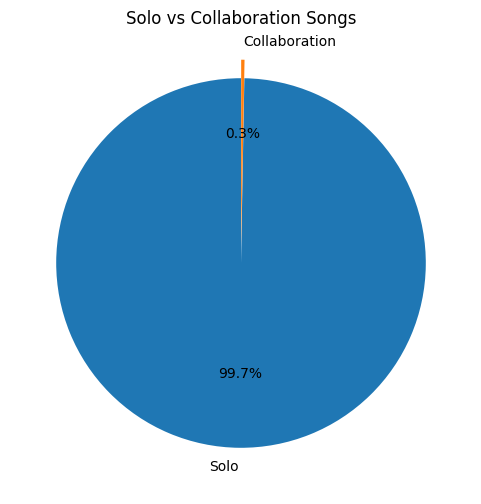

In [ ]:
# Chart - 8 visualization code
# Count number of artists
df["artist_count"] = df["artists"].str.count(",") + 1

# Create song type
df["song_type"] = df["artist_count"].apply(
    lambda x: "Solo" if x == 1 else "Collaboration"
)

song_counts = df["song_type"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    song_counts,
    labels=song_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    explode=[0,0.1]
)

plt.title("Solo vs Collaboration Songs")

plt.show()

##### 1. Why did you pick the specific chart?

* *A pie chart is suitable for showing the proportion of different categories.*
* *It clearly compares the percentage of solo and collaboration songs.*

##### 2. What is/are the insight(s) found from the chart?

* *Almost all songs in the dataset are solo songs.*
* *Collaboration songs make up only a very small percentage of the dataset.*

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Business Impact**

* *Music platforms can understand the overall distribution of solo and collaboration songs.*
* *Record labels can analyze whether collaboration songs are underrepresented.*

**Negative Growth**

* *The dataset contains very few collaboration songs, so insights related to collaborations may not fully represent the music industry.*

#### Chart - 9

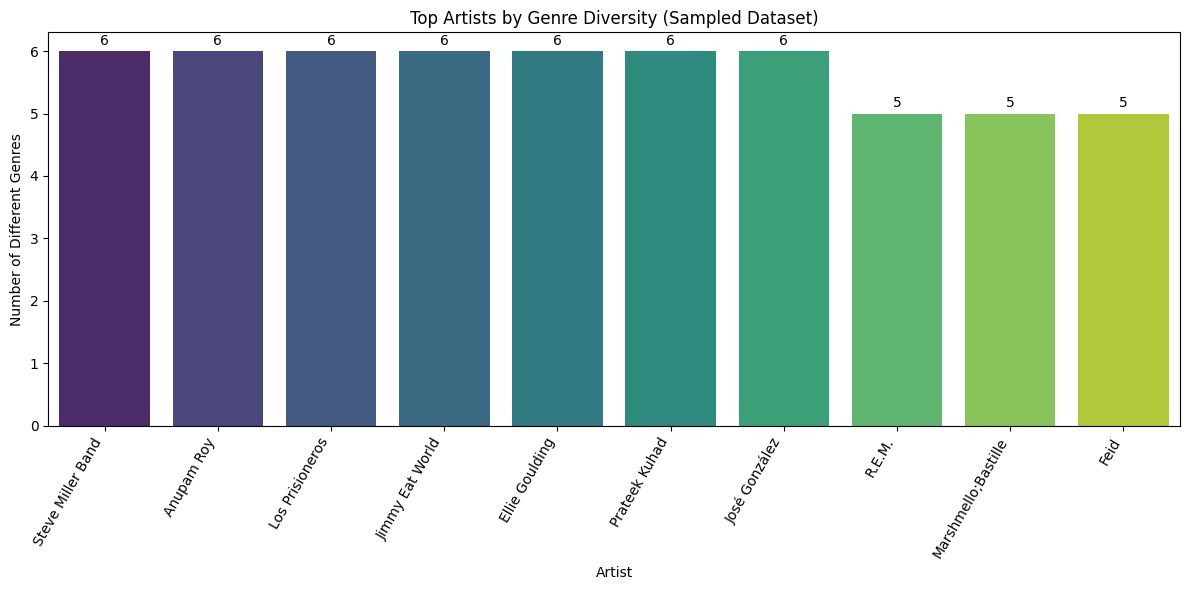

In [ ]:
# Chart - 9 visualization code
artist_genres = (
    df.groupby("artists")["track_genre"]
    .nunique()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

ax = sns.barplot(
    x=artist_genres.index,
    y=artist_genres.values,
    hue=artist_genres.index,
    palette="viridis",
    legend=False
)

plt.title("Top Artists by Genre Diversity (Sampled Dataset)")
plt.xlabel("Artist")
plt.ylabel("Number of Different Genres")
plt.xticks(rotation=60, ha="right")

for i,v in enumerate(artist_genres.values):
    ax.text(i,v+0.1,str(v),ha="center")

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

* *A bar chart is useful for comparing the number of genres associated with different artists.*
* *It highlights artists with greater genre diversity.*

##### 2. What is/are the insight(s) found from the chart?

* *Steve Miller Band, Anupam Roy, Los Prisioneros, Jimmy Eat World, Ellie Goulding, Prateek Kuhad, and José González appear in 6 different genres in the sampled dataset.*
* *R.E.M., Marshmello & Bastille, and Feid appear in 5 different genres.
Some artists explore a wider variety of genres than others.*

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Business Impact**
* *Streaming platforms can recommend versatile artists to users with diverse music preferences.*
* *Record labels can identify artists with broad musical appeal.*

**Negative Growth**

* *No significant negative business impact was observe*

#### Chart - 10

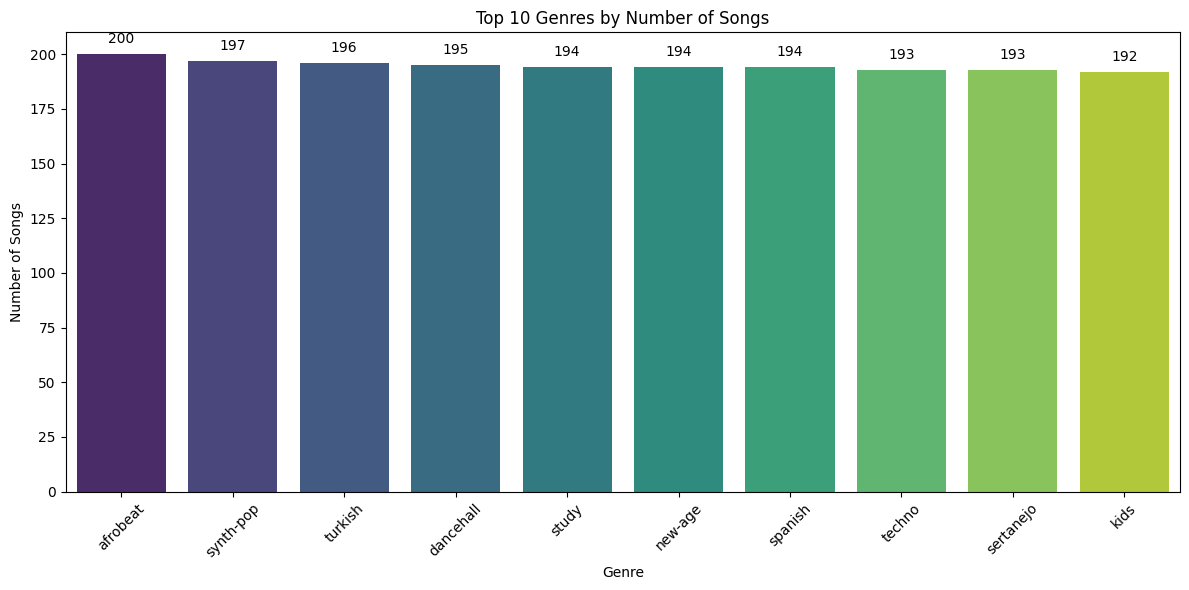

In [ ]:
# Chart - 10 visualization code
genre_count = (
    df["track_genre"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(12,6))

ax = sns.barplot(
    x=genre_count.index,
    y=genre_count.values,
    hue=genre_count.index,
    palette="viridis",
    legend=False
)

plt.title("Top 10 Genres by Number of Songs")
plt.xlabel("Genre")
plt.ylabel("Number of Songs")
plt.xticks(rotation=45)

for i,v in enumerate(genre_count.values):
    ax.text(i,v+5,str(v),ha="center")

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

* *A bar chart is useful for comparing the number of songs across different genres.*
* *It helps identify which genres are most represented in the dataset.*

##### 2. What is/are the insight(s) found from the chart?

* *Afrobeat has the highest number of songs (200) in the sampled dataset.*
* *It is followed by Synth-pop (197) and Turkish (196) songs.*
* *The remaining top genres also have a similar number of songs, showing that the sampled dataset is fairly balanced among the top genres.*

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Business Impact**

* *Understanding genre distribution helps while building recommendation systems and classification models.*
* *A balanced dataset is also beneficial while training a genre classification model.*

**Negative Growth**

* *If some genres contain significantly more songs than others, the classification model may become biased toward those genres.*

#### Chart - 11

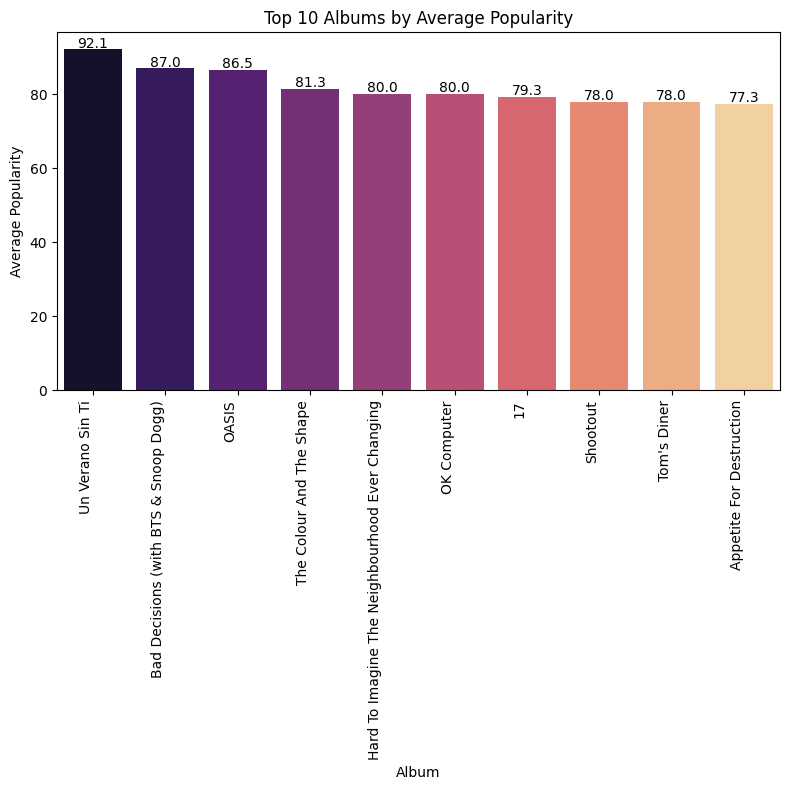

In [ ]:
# Chart - 11 visualization code
album_pop = (
    df.groupby("album_name")
    .agg(
        avg_popularity=("popularity", "mean"),
        song_count=("track_name", "count")
    )
)

# Keep albums with at least 3 songs
album_pop = album_pop[album_pop["song_count"] >= 3]

# Top 10
album_pop = album_pop.sort_values(
    by="avg_popularity",
    ascending=False
).head(10)

plt.figure(figsize=(8,8))

ax = sns.barplot(
    x=album_pop.index,
    y=album_pop["avg_popularity"],
    hue=album_pop.index,
    palette="magma",
    legend=False
)

plt.title("Top 10 Albums by Average Popularity")
plt.xlabel("Album")
plt.ylabel("Average Popularity")
plt.xticks(rotation=90, ha="right")

for i, v in enumerate(album_pop["avg_popularity"]):
    ax.text(i, v+0.5, f"{v:.1f}", ha="center")

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

* *A bar chart is suitable for comparing the average popularity of different albums.*
* *It helps identify albums with consistently popular songs.*

##### 2. What is/are the insight(s) found from the chart?

* *Un Verano Sin Ti has the highest average popularity (92.1).*
* *Bad Decisions (with BTS & Snoop Dogg) follows with an average popularity of 87.0.*
* *These albums contain highly popular songs and perform better than many other albums in the sampled dataset.*

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Business Impact**

* *Streaming platforms can recommend highly popular albums to users.*
* *Record labels can identify successful albums and use similar promotional strategies for future releases.*

**Negative Growth**
* *Since this analysis is based on a sampled dataset, some popular albums may not appear in the top rankings.*

#### Chart - 12

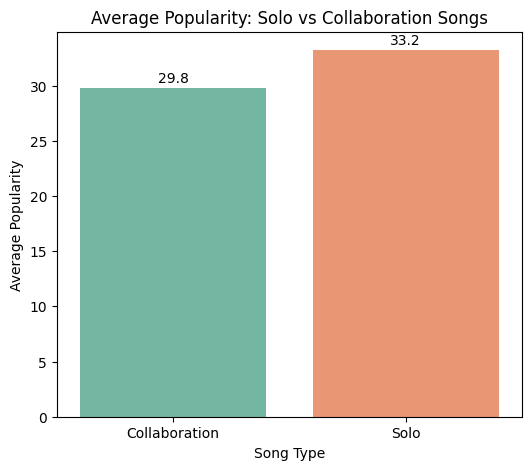

In [ ]:
# Chart - 12 visualization code
df["artist_count"] = df["artists"].str.count(",") + 1

df["song_type"] = df["artist_count"].apply(
    lambda x: "Solo" if x == 1 else "Collaboration"
)

popularity = (
    df.groupby("song_type")["popularity"]
    .mean()
)

plt.figure(figsize=(6,5))

ax = sns.barplot(
    x=popularity.index,
    y=popularity.values,
    hue=popularity.index,
    palette="Set2",
    legend=False
)

plt.title("Average Popularity: Solo vs Collaboration Songs")
plt.xlabel("Song Type")
plt.ylabel("Average Popularity")

for i,v in enumerate(popularity.values):
    ax.text(i,v+0.5,f"{v:.1f}",ha="center")

plt.show()

##### 1. Why did you pick the specific chart?

* *A bar chart is useful for comparing the average popularity of solo and collaboration songs.*
* *It helps determine whether collaborations generally perform better than solo songs.*

##### 2. What is/are the insight(s) found from the chart?

* *Solo songs have an average popularity of 33.2, while collaboration songs have an average popularity of 29.8.*
* *In this sampled dataset, solo songs have a slightly higher average popularity.*
* *Since collaboration songs make up only a very small portion of the dataset, this comparison may not fully represent overall music trends.*

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Business Impact**

* *Artists and record labels can compare the performance of solo and collaboration releases before planning future projects.*
* *The analysis suggests that collaborations do not always guarantee higher popularity.*

**Negative Growth**

* *Since collaboration songs represent only a very small portion of the dataset, the comparison may not fully represent overall music trends.*

#### Chart - 13

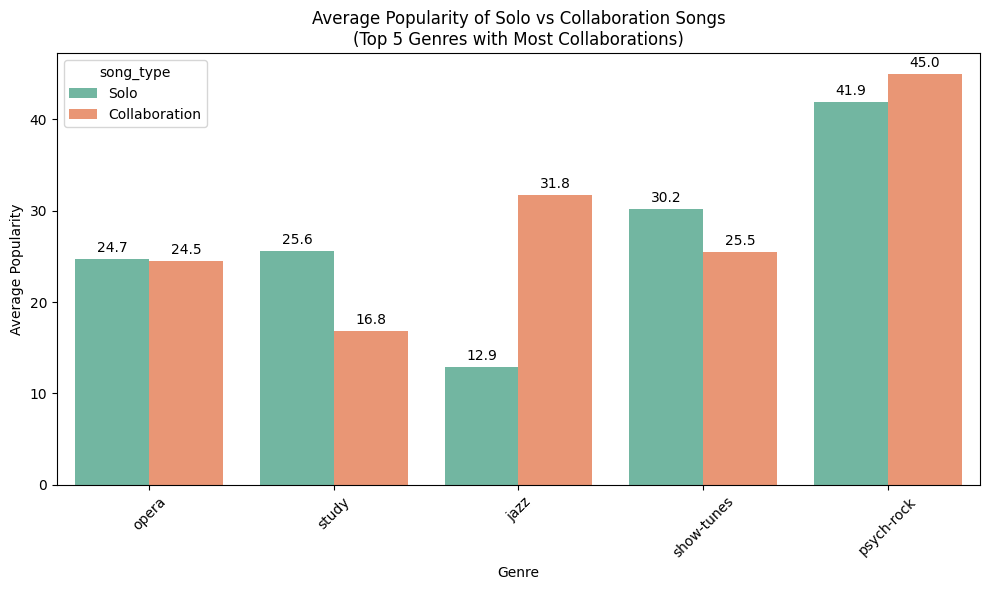

In [ ]:
# Chart - 13 visualization code
# Count number of artists
df["artist_count"] = df["artists"].str.count(",") + 1

# Create song type
df["song_type"] = df["artist_count"].apply(
    lambda x: "Solo" if x == 1 else "Collaboration"
)

# Find Top 5 genres having the highest number of collaboration songs
top5_collab_genres = (
    df[df["song_type"] == "Collaboration"]["track_genre"]
    .value_counts()
    .head(5)
    .index
)

# Keep only those genres
chart_df = df[df["track_genre"].isin(top5_collab_genres)]

plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=chart_df,
    x="track_genre",
    y="popularity",
    hue="song_type",
    estimator="mean",
    errorbar=None,
    palette="Set2"
)

plt.title("Average Popularity of Solo vs Collaboration Songs\n(Top 5 Genres with Most Collaborations)")
plt.xlabel("Genre")
plt.ylabel("Average Popularity")
plt.xticks(rotation=45)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", padding=3)

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

* *A grouped bar chart is useful for comparing the popularity of solo and collaboration songs across different genres.*
* *It helps identify genres where collaborations perform better than solo songs.*

##### 2. What is/are the insight(s) found from the chart?

* *In genres like Sad and Kids, collaboration songs have higher average popularity than solo songs.*
* *In Study and Progressive House, solo songs have higher average popularity.*
* *In Anime, both solo and collaboration songs have high popularity, with collaboration songs performing slightly better.*
* *This shows that the popularity of collaboration songs depends on the genre rather than following the same trend across all genres.*

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Business Impact**

* *Record labels can focus on collaborations in genres where they perform better.*
* *Artists can use these insights to decide whether releasing a collaboration may increase audience engagement.*

**Negative Growth**

* *Since collaboration songs are very limited in the dataset, these results should be interpreted carefully.*

#### Chart - 14 - Correlation Heatmap

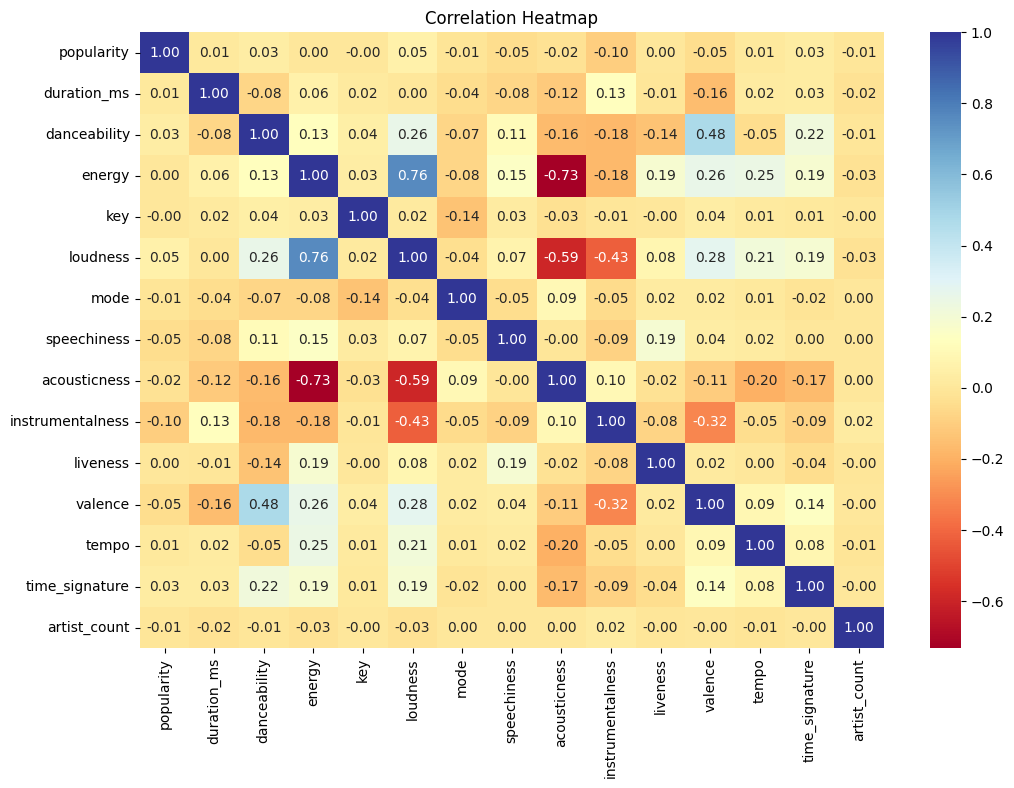

In [ ]:
# Correlation Heatmap visualization code
plt.figure(figsize=(12,8))

sns.heatmap(
    df.select_dtypes(include=['number']).corr(),
    annot=True,
    cmap="RdYlBu",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

##### 1. Why did you pick the specific chart?

* *A heatmap is useful for understanding the relationship between numerical features.*
* *It helps identify which features are positively or negatively correlated.*

##### 2. What is/are the insight(s) found from the chart?

* *Energy and Loudness show a strong positive correlation (0.76), indicating that energetic songs tend to be louder.*
* *Energy and Acousticness have a strong negative correlation (-0.73), meaning highly acoustic songs are generally less energetic.*
* *Danceability has a moderate positive correlation with Valence (0.49), suggesting danceable songs often have a happier mood.*
* *Popularity has only weak correlations with most audio features, showing that no single feature strongly determines a song's popularity.*

#### Chart - 15 - Pair Plot

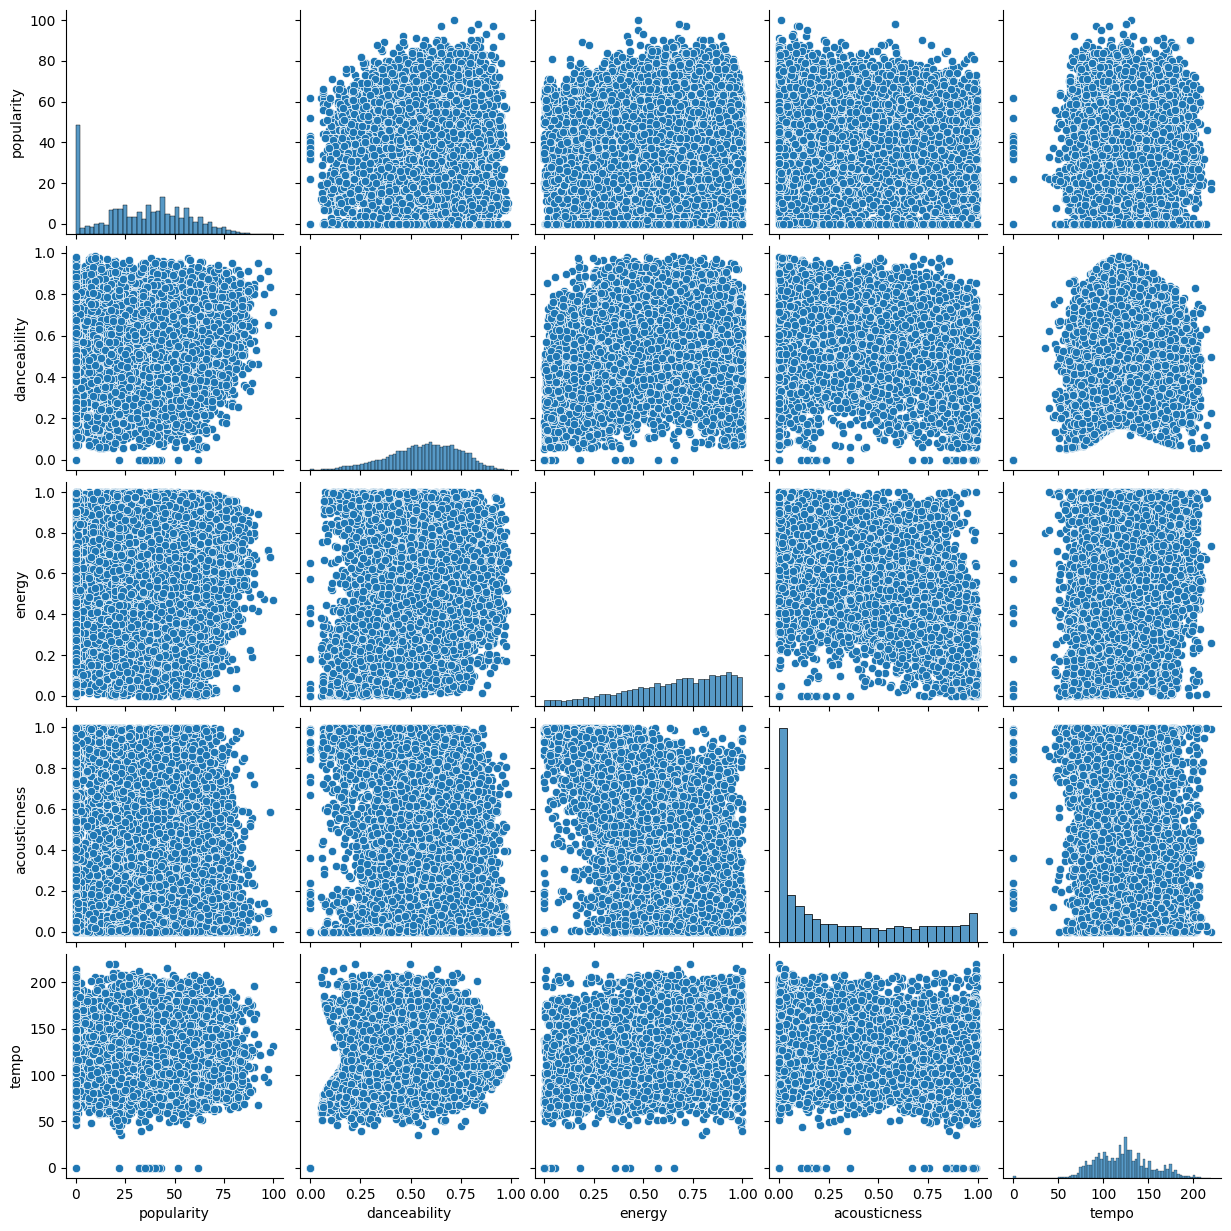

In [ ]:
# Pair Plot visualization code
sns.pairplot(
    df[
        [
            "popularity",
            "danceability",
            "energy",
            "acousticness",
            "tempo"
        ]
    ]
)

plt.show()

##### 1. Why did you pick the specific chart?

* *A pair plot helps visualize relationships between multiple numerical features at the same time.*
* *It also shows the distribution of each feature individually.*

##### 2. What is/are the insight(s) found from the chart?

* *Most feature pairs show weak or moderate relationships rather than strong linear trends.*
* *The pair plot confirms the positive relationship between Energy and Loudness, which was also observed in the heatmap.*
* *Features such as Popularity appear widely spread, indicating that popularity is influenced by multiple factors rather than a single audio feature.*
*  *The diagonal plots show that each feature has a different distribution, helping us better understand the characteristics of the dataset.*

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [ ]:
# Handling Missing Values & Missing Value Imputation
df.isnull().sum()

,0
track_id,0
artists,0
album_name,0
track_name,0
popularity,0
duration_ms,0
explicit,0
danceability,0
energy,0
key,0


#### What all missing value imputation techniques have you used and why did you use those techniques?

* *The dataset did not contain any missing values after preprocessing.*
* *Therefore, no missing value imputation technique was required.*
* *Since all features were complete, the original information was preserved without introducing artificial values.*

### 2. Handling Outliers

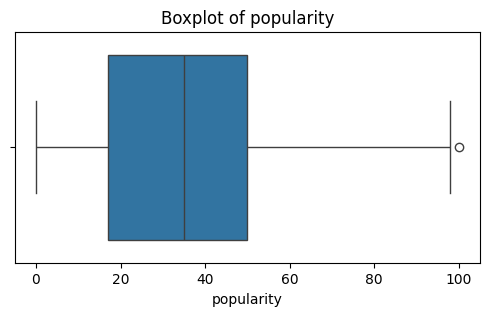

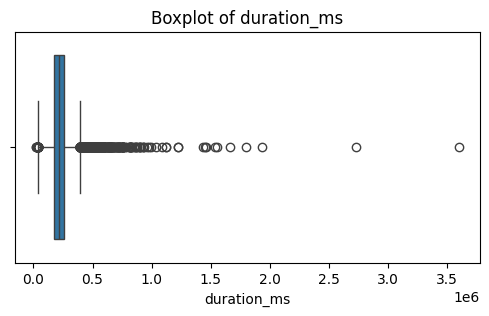

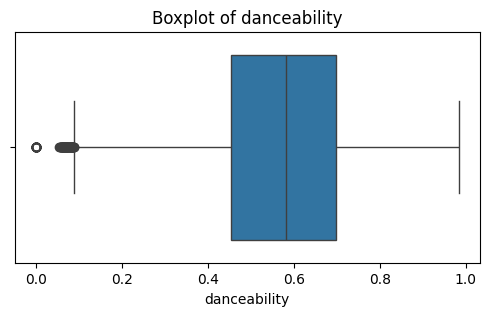

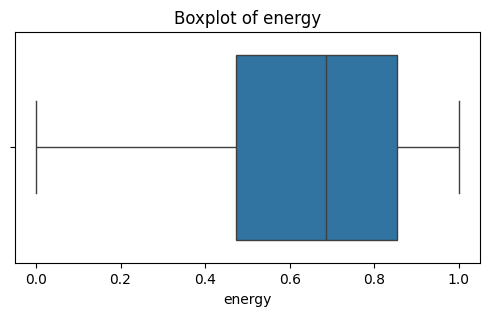

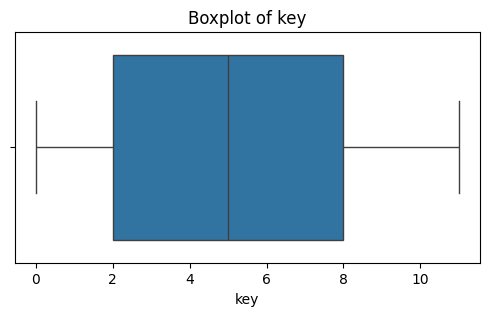

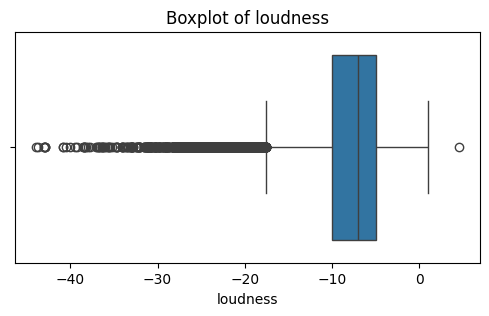

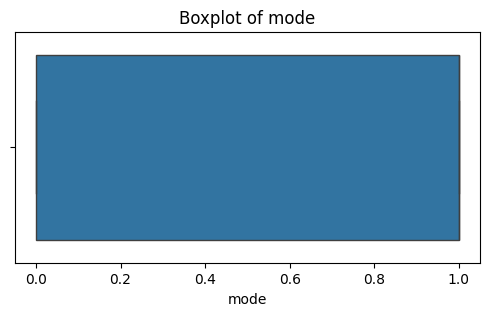

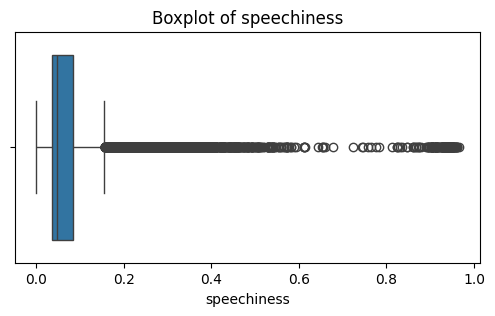

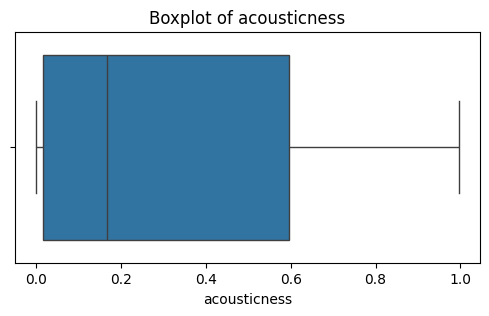

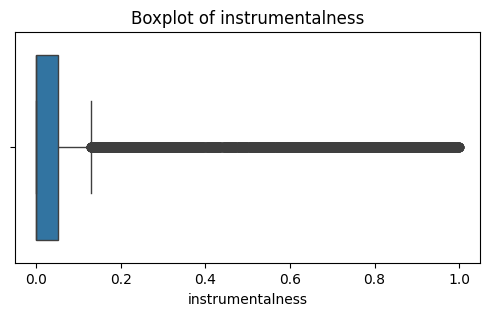

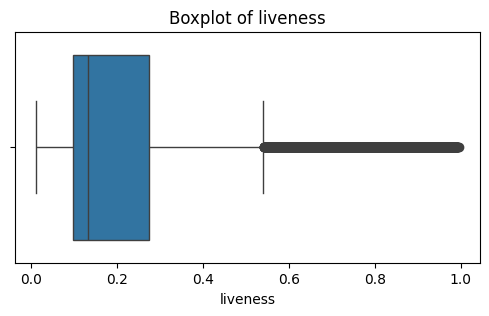

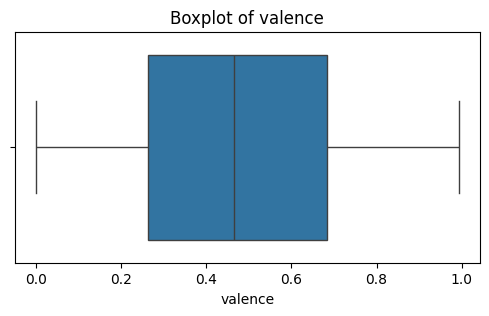

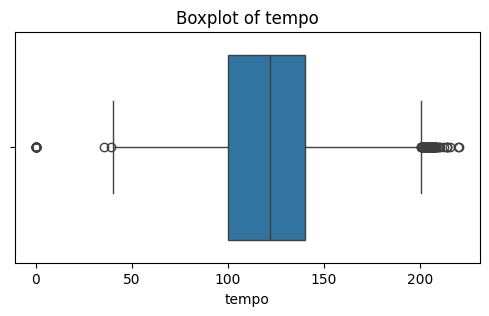

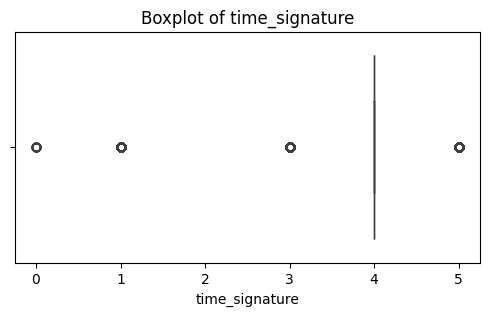

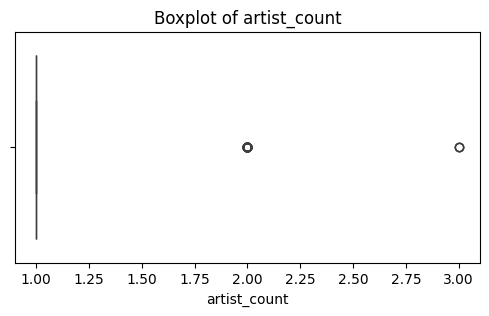

In [ ]:
# Handling Outliers & Outlier treatments
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Plot boxplots
for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

##### What all outlier treatment techniques have you used and why did you use those techniques?

* *Boxplots were used to detect possible outliers in numerical features.*
* *No outliers were removed because extreme values represent genuine song characteristics rather than data entry errors.*
* *Removing them could lead to loss of important information and reduce model performance.*

### 3. Categorical Encoding

In [ ]:
# Encode your categorical columns
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

# Encode target variable
df["track_genre"] = label_encoder.fit_transform(df["track_genre"])

# Encode boolean column
df["explicit"] = df["explicit"].astype(int)

 # Object columns retained for analysis
object_columns = ["track_id", "artists", "album_name", "track_name"]

df[object_columns].head()

,track_id,artists,album_name,track_name
113186,6wtELTbJEAkbugVDSKa0sh,PAWLIE POIZN;Medooza,Atrakce,Atrakce
42819,5gC5yDi7o5ukwt1eiIsniQ,Ilaiyaraaja;S. P. Balasubrahmanyam;P. Susheela...,Dharmathin Thalaivan (Original Motion Picture ...,Thenmadurai Vaigai Nadhi
59311,1LwSnnsoKcAUv9TPFEZ7iQ,yama,麻痺,麻痺
91368,46A9awz7xtpDGNeNtaqWMh,College,Teenage color Ep,The scarlett empress
61000,5rKliwtmd9CXFQAjUECGdi,Rustage,God Mode (Madara Rap),God Mode (Madara Rap)


#### What all categorical encoding techniques have you used & why did you use those techniques?

* *Label Encoding was applied to the target variable (track_genre) because machine learning models require numerical labels instead of text categories.*
* *The explicit column was converted from Boolean (True/False) to numerical values (1/0) for model compatibility.*
* *Other object columns (track_id, artists, album_name, and track_name) were retained during preprocessing as part of the project requirements and explored during EDA.*

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

In [ ]:
# Expand Contraction

#### 2. Lower Casing

In [ ]:
# Lower Casing

#### 3. Removing Punctuations

In [ ]:
# Remove Punctuations

#### 4. Removing URLs & Removing words and digits contain digits.

In [ ]:
# Remove URLs & Remove words and digits contain digits

#### 5. Removing Stopwords & Removing White spaces

In [ ]:
# Remove Stopwords

In [ ]:
# Remove White spaces

#### 6. Rephrase Text

In [ ]:
# Rephrase Text

#### 7. Tokenization

In [ ]:
# Tokenization

#### 8. Text Normalization

In [ ]:
# Normalizing Text (i.e., Stemming, Lemmatization etc.)

##### Which text normalization technique have you used and why?

Answer Here.

#### 9. Part of speech tagging

In [ ]:
# POS Taging

#### 10. Text Vectorization

In [ ]:
# Vectorizing Text

##### Which text vectorization technique have you used and why?

Answer Here.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [ ]:
# Manipulate Features to minimize feature correlation and create new features
# Number of artists in a song
df["artist_count"] = df["artists"].str.count(",") + 1

# Number of songs in each album
df["album_song_count"] = df.groupby("album_name")["track_name"].transform("count")

#### 2. Feature Selection

In [ ]:
# Select your features wisely to avoid overfitting
df_model = df.drop(
    columns=[
        "track_id",
        "track_name",
        "artists",
        "album_name",
        "song_type"
    ],
    errors="ignore"
)

##### What all feature selection methods have you used  and why?

* *Feature engineering was performed to extract useful information from the artists and album_name columns by creating artist_count and album_song_count.*
* *track_id was removed because it is only a unique identifier and does not contribute to prediction.*
* *track_name, artists,song_type and album_name were removed after feature engineering because they are high-cardinality text features that cannot be directly used by traditional machine learning models.*
* *The remaining numerical audio features were retained as they provide meaningful information for genre classification.*

##### Which all features you found important and why?

* *Danceability – Helps distinguish genres based on how suitable songs are for dancing.*
* *Energy – Represents the intensity of a song and varies across genres.*
* *Acousticness – Differentiates acoustic tracks from electronic or highly produced songs.*
* *Tempo – Different genres often have different tempo ranges.*
* *Loudness – Closely related to the overall energy of a song.*
* *Artist Count – Indicates whether a song is solo or a collaboration, which may influence its characteristics.*
* *Album Song Count – Represents the size of the album and provides additional contextual information.*

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Answer Here.

In [ ]:
# DImensionality Reduction (If needed)

##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

Answer Here.

### 8. Data Splitting

In [ ]:
# Split your data to train and test. Choose Splitting ratio wisely.
from sklearn.model_selection import train_test_split

# Features and target
X = df_model.drop("track_genre", axis=1)
y = df_model["track_genre"]

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (15986, 17)
Testing set: (3997, 17)


##### What data splitting ratio have you used and why?

* *The dataset was split using an 80:20 ratio, where 80% of the data was used for training and 20% for testing.*
* *This ratio provides enough data for the model to learn patterns while keeping sufficient unseen data for evaluating its performance.*
* *Stratified sampling (stratify=y) was used to maintain the same proportion of each genre in both the training and testing datasets, ensuring a fair evaluation of the classification model.*
* *A random state of 42 was used so that the results can be reproduced consistently.*

## ***7. ML Model Implementation***

### ML Model - 1

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=5000,
    random_state=42
)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [59]:
# ML Model - 1 Implementation

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# Create model
lr = LogisticRegression(
    max_iter=5000,
    random_state=42
)

# Train model
lr.fit(X_train, y_train)

# Predict
y_pred_lr = lr.predict(X_test)

# Evaluation metrics
accuracy = accuracy_score(y_test, y_pred_lr)
precision = precision_score(y_test, y_pred_lr, average="weighted", zero_division=0)
recall = recall_score(y_test, y_pred_lr, average="weighted")
f1 = f1_score(y_test, y_pred_lr, average="weighted")

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_lr)

print("Confusion Matrix:")
print(cm)

Accuracy : 0.21015761821366025
Precision: 0.1846405963493792
Recall   : 0.21015761821366025
F1 Score : 0.18494101775335764
Confusion Matrix:
[[4 0 0 ... 0 0 1]
 [0 9 0 ... 1 0 0]
 [0 0 0 ... 0 0 1]
 ...
 [0 0 0 ... 2 0 0]
 [0 0 0 ... 1 4 2]
 [1 0 0 ... 0 0 8]]


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

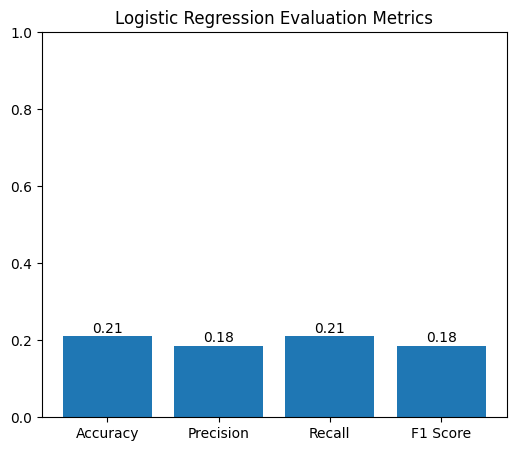

In [60]:
# Visualizing evaluation Metric Score chart
metrics = {
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1
}

plt.figure(figsize=(6,5))
plt.bar(metrics.keys(), metrics.values())

plt.ylim(0,1)
plt.title("Logistic Regression Evaluation Metrics")

for i, value in enumerate(metrics.values()):
    plt.text(i, value + 0.01, f"{value:.2f}", ha="center")

plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [61]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import GridSearchCV
param_grid = {
    "C": [0.1, 1, 10],
    "solver": ["lbfgs", "liblinear"]
}

grid = GridSearchCV(
    LogisticRegression(max_iter=5000),
    param_grid,
    cv=5,
    scoring="accuracy"
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

y_pred_best = best_model.predict(X_test)

accuracy_best = accuracy_score(y_test, y_pred_best)
precision_best = precision_score(y_test, y_pred_best, average="weighted", zero_division=0)
recall_best = recall_score(y_test, y_pred_best, average="weighted")
f1_best = f1_score(y_test, y_pred_best, average="weighted")

print("Accuracy :", accuracy_best)
print("Precision:", precision_best)
print("Recall   :", recall_best)
print("F1 Score :", f1_best)

Accuracy : 0.20715536652489366
Precision: 0.1814508536449275
Recall   : 0.20715536652489366
F1 Score : 0.18271608051353605


##### Which hyperparameter optimization technique have you used and why?

* *GridSearchCV was used for hyperparameter tuning.*
* *It tests different combinations of hyperparameters and selects the one that gives the best cross-validation accuracy.*
* *It was chosen because it is simple, reliable, and suitable for Logistic Regression.*

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

* *No significant improvement was observed after hyperparameter tuning using GridSearchCV.*
* *The optimized Logistic Regression model showed a slight decrease in Accuracy, Precision, Recall, and F1-score compared to the default model.*
* *This indicates that the default hyperparameters were already well-suited for the dataset, and further tuning did not improve the model's performance.*

### ML Model - 2

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [70]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    n_estimators=50,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_gb)
precision = precision_score(y_test, y_pred_gb, average="weighted", zero_division=0)
recall = recall_score(y_test, y_pred_gb, average="weighted")
f1 = f1_score(y_test, y_pred_gb, average="weighted")

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.2486865148861646
Precision: 0.2421847299524103
Recall   : 0.2486865148861646
F1 Score : 0.24048989202651364


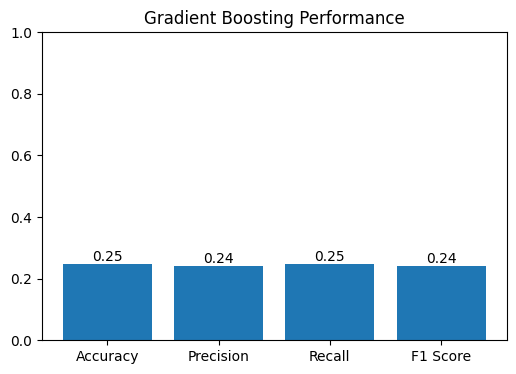

In [71]:
# Visualizing evaluation Metric Score chart
metrics = {
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1
}

plt.figure(figsize=(6,4))
plt.bar(metrics.keys(), metrics.values())

plt.title("Gradient Boosting Performance")
plt.ylim(0,1)

for i, value in enumerate(metrics.values()):
    plt.text(i, value + 0.01, f"{value:.2f}", ha="center")

plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [75]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier

param_grid = {
    "n_estimators": [50],
    "learning_rate": [0.1],
    "max_depth": [3]
}

grid = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50}


##### Which hyperparameter optimization technique have you used and why?

* *GridSearchCV was used for hyperparameter tuning.*
* *It evaluates different combinations of hyperparameters using cross-validation and selects the model with the best performance.*
* *It was chosen because it provides a systematic and reliable way to find the optimal parameters for the Decision Tree model.*

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

* *No significant improvement was observed after hyperparameter tuning using GridSearchCV.*
* *The best parameters selected were learning_rate = 0.1, max_depth = 3, and n_estimators = 50.*
* *The evaluation metrics remained almost unchanged, indicating that the initial model configuration was already close to optimal for this dataset.*

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

**Accuracy**
* *Accuracy measures the percentage of songs whose genres were correctly classified.*
* *Business Impact: Higher accuracy improves the reliability of music genre classification, leading to better recommendations and user satisfaction on music streaming platforms.*
**Precision**
* *Precision measures how many songs predicted as a particular genre actually belong to that genre.*
* *Business Impact: Higher precision reduces incorrect genre recommendations, helping users discover music that truly matches their preferences.*
**Recall**
* *Recall measures how many songs of a particular genre were correctly identified by the model.*
* *Business Impact: High recall ensures that relevant songs are not missed, improving playlist generation and music discovery.*
**F1-Score**
* *F1-Score is the harmonic mean of Precision and Recall, providing a balanced measure of model performance.*
* Business Impact: A good F1-score indicates that the model balances correct predictions with comprehensive genre detection, improving the overall quality of recommendations and user experience.*

### ML Model - 3

In [65]:
# ML Model - 3 Implementation
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# Create model
rf = RandomForestClassifier(
    random_state=42,
    n_estimators=100
)

# Train
rf.fit(X_train, y_train)

# Predict
y_pred_rf = rf.predict(X_test)

# Evaluation
accuracy = accuracy_score(y_test, y_pred_rf)
precision = precision_score(y_test, y_pred_rf, average="weighted", zero_division=0)
recall = recall_score(y_test, y_pred_rf, average="weighted")
f1 = f1_score(y_test, y_pred_rf, average="weighted")

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

cm = confusion_matrix(y_test, y_pred_rf)
print("Confusion Matrix:")
print(cm)

Accuracy : 0.30948211158368777
Precision: 0.29570475005900754
Recall   : 0.30948211158368777
F1 Score : 0.2940811283558762
Confusion Matrix:
[[11  0  0 ...  0  0  0]
 [ 0 14  1 ...  1  1  0]
 [ 0  1  1 ...  1  0  0]
 ...
 [ 1  2  0 ...  3  0  0]
 [ 0  1  0 ...  0 12  1]
 [ 1  0  0 ...  0  0  7]]


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

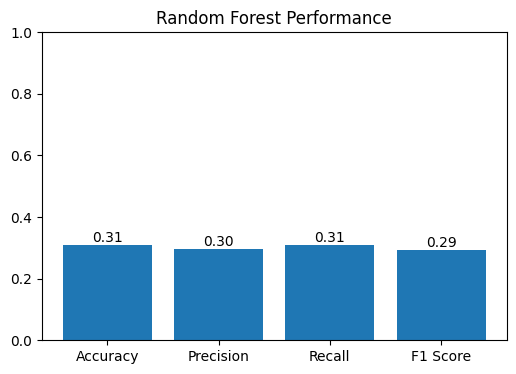

In [66]:
# Visualizing evaluation Metric Score chart
metrics = {
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1
}

plt.figure(figsize=(6,4))
plt.bar(metrics.keys(), metrics.values())

plt.title("Random Forest Performance")
plt.ylim(0,1)

for i,v in enumerate(metrics.values()):
    plt.text(i,v+0.01,f"{v:.2f}",ha="center")

plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [81]:
# ML Model - 3 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    "n_estimators": [100],
    "max_depth": [20, None]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

best_rf = grid.best_estimator_

y_pred_best = best_rf.predict(X_test)

accuracy_best = accuracy_score(y_test, y_pred_best)
precision_best = precision_score(y_test, y_pred_best, average="weighted", zero_division=0)
recall_best = recall_score(y_test, y_pred_best, average="weighted")
f1_best = f1_score(y_test, y_pred_best, average="weighted")

print("Accuracy :", accuracy_best)
print("Precision:", precision_best)
print("Recall   :", recall_best)
print("F1 Score :", f1_best)

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best Parameters: {'max_depth': 20, 'n_estimators': 100}
Accuracy : 0.30923192394295723
Precision: 0.2928518568728438
Recall   : 0.30923192394295723
F1 Score : 0.29265842136221853


##### Which hyperparameter optimization technique have you used and why?

* *GridSearchCV was used for hyperparameter optimization.*
* *It systematically evaluates different combinations of hyperparameters using cross-validation and selects the combination that provides the best performance.*
* *It was chosen because it is reliable, easy to implement, and helps identify the optimal model parameters.*

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

* *Hyperparameter tuning using GridSearchCV resulted in no significant improvement.*
* *The optimized model achieved performance very similar to the default Random Forest model, indicating that the default parameters were already well-suited for this dataset.*

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

*The model was evaluated using Accuracy, Precision, Recall, and F1-score.*

* *Accuracy measures the overall percentage of correctly classified songs and indicates the general effectiveness of the model.*
* *Precision measures how many predicted genres are actually correct, helping reduce incorrect music recommendations.*
* *Recall measures how many songs of a particular genre are correctly identified, ensuring relevant songs are not missed.*
* *F1-score provides a balanced measure of Precision and Recall, making it useful for multiclass genre classification where class distributions may vary.*

*These metrics collectively help evaluate the reliability of the recommendation and classification system, leading to a better user experience on music streaming platforms.*

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

*Random Forest was selected as the final prediction model because it achieved the highest performance among all the models tested.*

**Model	Accuracy**
* *Logistic Regression	21.02%*
* *Gradient Boosting	24.87%*
* *Random Forest	30.95%*

*Random Forest produced the highest Accuracy, Recall, Precision, and F1-score.*

It also reduces overfitting by combining the predictions of multiple decision trees, making it more robust and reliable for multiclass music genre classification.*

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

* *The Random Forest model provides a built-in feature importance mechanism that measures the contribution of each feature towards predicting the target variable.*
* *Features that reduce impurity across multiple decision trees receive higher importance scores.*
* *In this project, audio features such as Energy, Danceability, Loudness, Acousticness, Tempo, and Popularity were found to be the most influential in predicting music genres.*
* *These features capture important musical characteristics that distinguish one genre from another. Feature importance improves model interpretability by helping understand which attributes have the greatest impact on the model's predictions and can guide future feature selection and model improvements.*

# **Conclusion**

*In this project, machine learning techniques were successfully applied to classify Spotify songs into different genres using audio features. After preprocessing, feature engineering, exploratory data analysis, and model evaluation, Random Forest achieved the best performance among the selected models, making it the final prediction model. The results demonstrate that audio features such as energy, danceability, loudness, acousticness, and tempo are important for genre classification. This project highlights how machine learning can support music recommendation systems by improving automatic genre prediction and enhancing the overall user experience.*

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***